In [40]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [47]:
# load data
X,y = make_moons(n_samples=600, noise=0.25, random_state=42)

In [48]:
# split data
X_train,X_test, y_train,y_test = train_test_split(X,y, test_size=0.3, random_state=42)

# Pre-Pruning

In [49]:
depths = list(range(1,16))

train_accuracies = []
test_accuracies = []

for d in depths:
    model = DecisionTreeClassifier(
        max_depth=d,
        min_samples_leaf=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, train_pred)
    train_accuracies.append(train_accuracy)

    test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, test_pred)
    test_accuracies.append(test_accuracy)

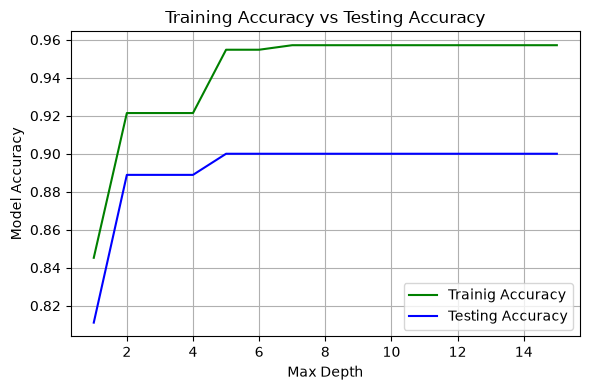

In [50]:
# Visualize the pre-pruned model accuracies

plt.figure(figsize=(6,4))

plt.plot(depths, train_accuracies, color="green", label="Trainig Accuracy")
plt.plot(depths, test_accuracies, color="blue", label="Testing Accuracy")

plt.title("Training Accuracy vs Testing Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Model Accuracy")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

# Post-Pruning

In [51]:
# train full exhastive tree
full_model = DecisionTreeClassifier(
    random_state=42
)
full_model.fit(X_train, y_train)

# calculate the pruning path
path = full_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

train_accuracies = []
test_accuracies = []

for ccp_alpha in ccp_alphas:
    pruned_model = DecisionTreeClassifier(
        ccp_alpha=ccp_alpha,
        random_state=42
    )

    pruned_model.fit(X_train, y_train)

    train_pred = pruned_model.predict(X_train)
    train_accuracy = accuracy_score(y_train, train_pred)
    train_accuracies.append(train_accuracy)

    test_pred = pruned_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, test_pred)
    test_accuracies.append(test_accuracy)

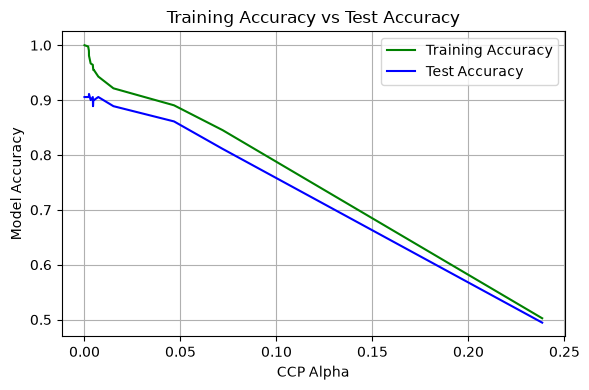

In [52]:
# Visualize the post-pruned tree accuracies

plt.figure(figsize=(6,4))

plt.plot(ccp_alphas, train_accuracies, color="green", label="Training Accuracy")
plt.plot(ccp_alphas, test_accuracies, color="blue", label="Test Accuracy")

plt.title("Training Accuracy vs Test Accuracy")
plt.xlabel("CCP Alpha")
plt.ylabel("Model Accuracy")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [53]:
# Best ccp_alpha
# Larger ccp_lapha, more aggressive pruning

optimal_ccp_alpha = ccp_alphas[np.argmax(test_accuracies)]

print(f"Optimal CCP Alpha is {optimal_ccp_alpha}")

Optimal CCP Alpha is 0.002330827067669173
